Advertising: DATAset

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

Reading the datset

In [31]:
df=pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [32]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [33]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


## **Step 4: Missing Values**

In [34]:
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


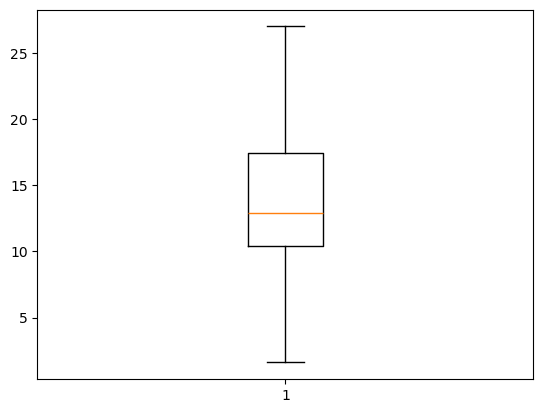

In [35]:
plt.boxplot(df['Sales'])
plt.show()

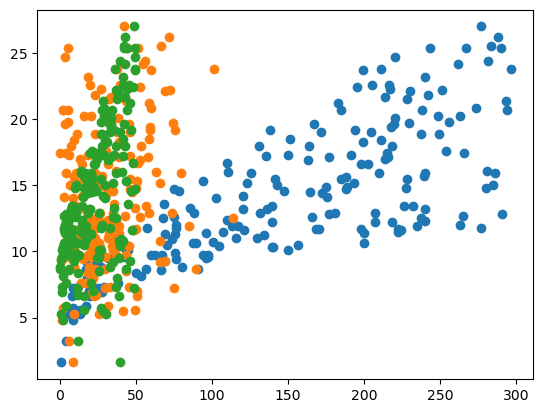

In [36]:
plt.scatter(df['TV'],df['Sales'])
plt.scatter(df['Newspaper'],df['Sales'])
plt.scatter(df['Radio'],df['Sales'])

In [37]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


In [38]:
X=df.drop(columns=['Sales'])
y=df['Sales']

In [39]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

In [40]:
model=LinearRegression()

In [41]:
model.fit(Xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.19,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.979
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [46]:
y_pred_train=model.predict(Xtrain)

In [48]:
y_pred_test=model.predict(Xtest)

## **Train Data**

In [49]:
mae = mean_absolute_error(ytrain, y_pred_train)
print("MAE:", mae)
mse = mean_squared_error(ytrain, y_pred_train)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(ytrain, y_pred_train)
print("R2 Score:", r2)

MAE: 1.1984678961500137
MSE: 2.705129423081414
RMSE: 1.644727765644337
R2 Score: 0.8957008271017818


## **Test Data**

In [50]:
mae = mean_absolute_error(ytest, y_pred_test)
print("MAE:", mae)
mse = mean_squared_error(ytest, y_pred_test)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(ytest, y_pred_test)
print("R2 Score:", r2)

MAE: 1.4607567168117606
MSE: 3.1740973539761046
RMSE: 1.7815996615334502
R2 Score: 0.899438024100912


In [51]:
comparision=pd.DataFrame({
    "Actual":ytest,
    "Predict":y_pred_test
})
print(comparision)

     Actual    Predict
95     16.9  16.408024
15     22.4  20.889882
30     21.4  21.553843
158     7.3  10.608503
128    24.7  22.112373
115    12.6  13.105592
69     22.3  21.057192
170     8.4   7.461010
174    11.5  13.606346
45     14.9  15.155070
66      9.5   9.048320
182     8.7   6.653283
165    11.9  14.345545
78      5.3   8.903493
186    10.3   9.689590
177    11.7  12.164944
56      5.5   8.736284
152    16.6  16.265073
82     11.3  10.277596
68     18.9  18.831091
124    19.7  19.560367
16     12.5  13.251035
148    10.9  12.336207
93     22.2  21.306951
65      9.3   7.827403
60      8.1   5.809574
84     21.7  20.757532
67     13.4  11.981381
125    10.6   9.183496
132     5.7   8.506699
9      10.6  12.466468
18     11.3  10.003377
55     23.7  21.387671
75      8.7  12.249664
150    16.1  18.266615
104    20.7  20.137663
135    11.6  14.055140
137    20.8  20.854112
164    11.9  11.017444
76      6.9   4.568996


In [54]:
new_data=[[6,15,3]]
prediction=model.predict(new_data)
print(prediction)

[6.0936536]


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
